<a href="https://colab.research.google.com/github/weathon/neg/blob/main/NAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ChenDarYen/Normalized-Attention-Guidance.git

fatal: destination path 'Normalized-Attention-Guidance' already exists and is not an empty directory.


In [2]:
!pip install -r Normalized-Attention-Guidance/requirements.txt -qq

In [3]:
import sys
sys.path.append("Normalized-Attention-Guidance")

In [4]:
from huggingface_hub import login

In [101]:
import math
from typing import Optional

import torch
import torch.nn.functional as F

from diffusers.models.attention_processor import Attention
from diffusers.models.embeddings import apply_rotary_emb
import pylab
import random

class NAGFluxAttnProcessor2_0:
    """Attention processor used typically in processing the SD3-like self-attention projections."""

    def __init__(
            self,
            nag_scale: float = 1.0,
            nag_tau=2.5,
            nag_alpha=0.25,
            encoder_hidden_states_length: int = None,
    ):
        if not hasattr(F, "scaled_dot_product_attention"):
            raise ImportError("FluxAttnProcessor2_0 requires PyTorch 2.0, to use it, please upgrade PyTorch to 2.0.")
        self.nag_scale = nag_scale
        self.nag_tau = nag_tau
        self.nag_alpha = nag_alpha
        self.encoder_hidden_states_length = encoder_hidden_states_length

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.FloatTensor,
        encoder_hidden_states: torch.FloatTensor = None,
        attention_mask: Optional[torch.FloatTensor] = None,
        image_rotary_emb: Optional[torch.Tensor] = None,
    ) -> torch.FloatTensor:
        batch_size, _, _ = hidden_states.shape if encoder_hidden_states is None else encoder_hidden_states.shape
        # print(hidden_states.shape)
        if self.nag_scale > 1.:
            if encoder_hidden_states is not None:
                assert len(hidden_states) == batch_size * 0.5
            apply_guidance = True
        else:
            apply_guidance = False

        # `sample` projections.
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        # attention
        if apply_guidance and encoder_hidden_states is not None:
            query = query.tile(2, 1, 1)
            key = key.tile(2, 1, 1)
            value = value.tile(2, 1, 1)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        # the attention in FluxSingleTransformerBlock does not use `encoder_hidden_states`
        if encoder_hidden_states is not None:
            # `context` projections.
            encoder_hidden_states_query_proj = attn.add_q_proj(encoder_hidden_states)
            encoder_hidden_states_key_proj = attn.add_k_proj(encoder_hidden_states)
            encoder_hidden_states_value_proj = attn.add_v_proj(encoder_hidden_states)

            encoder_hidden_states_query_proj = encoder_hidden_states_query_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_key_proj = encoder_hidden_states_key_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_value_proj = encoder_hidden_states_value_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)

            if attn.norm_added_q is not None:
                encoder_hidden_states_query_proj = attn.norm_added_q(encoder_hidden_states_query_proj)
            if attn.norm_added_k is not None:
                encoder_hidden_states_key_proj = attn.norm_added_k(encoder_hidden_states_key_proj)

            query = torch.cat([encoder_hidden_states_query_proj, query], dim=2)
            key = torch.cat([encoder_hidden_states_key_proj, key], dim=2)
            value = torch.cat([encoder_hidden_states_value_proj, value], dim=2)

            encoder_hidden_states_length = encoder_hidden_states.shape[1]

        else:
            assert self.encoder_hidden_states_length is not None
            encoder_hidden_states_length = self.encoder_hidden_states_length

        if image_rotary_emb is not None:
            query = apply_rotary_emb(query, image_rotary_emb)
            key = apply_rotary_emb(key, image_rotary_emb)

        if not apply_guidance:
            hidden_states = F.scaled_dot_product_attention(query, key, value, dropout_p=0.0, is_causal=False)
            hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
            hidden_states = hidden_states.to(query.dtype)

        else:
            origin_batch_size = batch_size // 2
            query, query_negative = torch.chunk(query, 2, dim=0)
            key, key_negative = torch.chunk(key, 2, dim=0)
            value, value_negative = torch.chunk(value, 2, dim=0)

            if encoder_hidden_states is not None:
              encoder_neg_query = query_negative[:,:,:encoder_hidden_states_length]
              encoder_neg_key = key_negative[:,:,:encoder_hidden_states_length]
              encoder_neg_value = value_negative[:,:,:encoder_hidden_states_length]
              query_pos_neg = torch.cat([encoder_neg_query, query], dim=2)
              key_pos_neg = torch.cat([encoder_neg_key, key], dim=2)
              value_pos_neg = torch.cat([- 1.2 * encoder_neg_value, value], dim=2)
            else:
              query_pos_neg, key_pos_neg, value_pos_neg = query, key, value
            hidden_states = F.scaled_dot_product_attention(query_pos_neg, key_pos_neg, value_pos_neg, dropout_p=0.0, is_causal=False)
            hidden_states = hidden_states.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
            hidden_states = hidden_states.to(query.dtype)

            hidden_states_positive = F.scaled_dot_product_attention(query, key, value, dropout_p=0.0, is_causal=False)
            hidden_states_positive = hidden_states_positive.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
            hidden_states_positive = hidden_states_positive.to(query.dtype)

            if encoder_hidden_states is not None:
              # hidden_states[:,encoder_hidden_states_length:2*encoder_hidden_states_length] -= hidden_states[:,:encoder_hidden_states_length]
              hidden_states = hidden_states[:,encoder_hidden_states_length:]

        if encoder_hidden_states is not None:
            encoder_hidden_states, hidden_states = (
                hidden_states[:, : encoder_hidden_states.shape[1]],
                hidden_states[:, encoder_hidden_states.shape[1] :],
            )

            if apply_guidance:
                encoder_hidden_states_positive, hidden_states_positive = (
                    hidden_states_positive[:, : encoder_hidden_states.shape[1]],
                    hidden_states_positive[:, encoder_hidden_states.shape[1]:],
                )
                norm_positive = torch.norm(hidden_states_positive, p=2, dim=-1, keepdim=True).expand(*hidden_states_positive.shape)
                norm_guidance = torch.norm(hidden_states, p=2, dim=-1, keepdim=True).expand(*hidden_states_positive.shape)

                scale = norm_guidance / norm_positive
                hidden_states = hidden_states * torch.minimum(scale, scale.new_ones(1) * self.nag_tau) / scale

                # hidden_states = hidden_states * self.nag_alpha + hidden_states_positive * (1 - self.nag_alpha)

                encoder_hidden_states = torch.cat((encoder_hidden_states, encoder_hidden_states_positive), dim=0)

            hidden_states = attn.to_out[0](hidden_states)
            hidden_states = attn.to_out[1](hidden_states)

            encoder_hidden_states = attn.to_add_out(encoder_hidden_states)
            # print(hidden_states.shape, encoder_hidden_states.shape)
            return hidden_states, encoder_hidden_states

        else:
            # print(hidden_states.shape)
            # return hidden_states
            return torch.cat([hidden_states, hidden_states], dim=0)

In [105]:
import torch
from src.pipeline_flux_nag import NAGFluxPipeline
from src.transformer_flux import NAGFluxTransformer2DModel
from src.attention_flux_nag import NAGFluxAttnProcessor2_0 as NAGFluxAttnProcessor2_0_vanilla

transformer = NAGFluxTransformer2DModel.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    subfolder="transformer",
    torch_dtype=torch.bfloat16,
)


def _set_nag_attn_processor(
        self,
        nag_scale,
        encoder_hidden_states_length,
        nag_tau=5,
        nag_alpha=0.8,
):
    attn_procs = {}
    for name in self.transformer.attn_processors.keys():
        attn_procs[name] = NAGFluxAttnProcessor2_0(
            nag_scale=nag_scale,
            nag_tau=nag_tau,
            nag_alpha=nag_alpha,
            encoder_hidden_states_length=encoder_hidden_states_length,
        )
    self.transformer.set_attn_processor(attn_procs)

if not "pipe" in locals():
  pipe = NAGFluxPipeline.from_pretrained(
      "black-forest-labs/FLUX.1-schnell",
      transformer=transformer,
      torch_dtype=torch.bfloat16,
  )
  pipe.to("cuda")
NAGFluxPipeline._set_nag_attn_processor = _set_nag_attn_processor

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

1750628292


  0%|          | 0/5 [00:00<?, ?it/s]

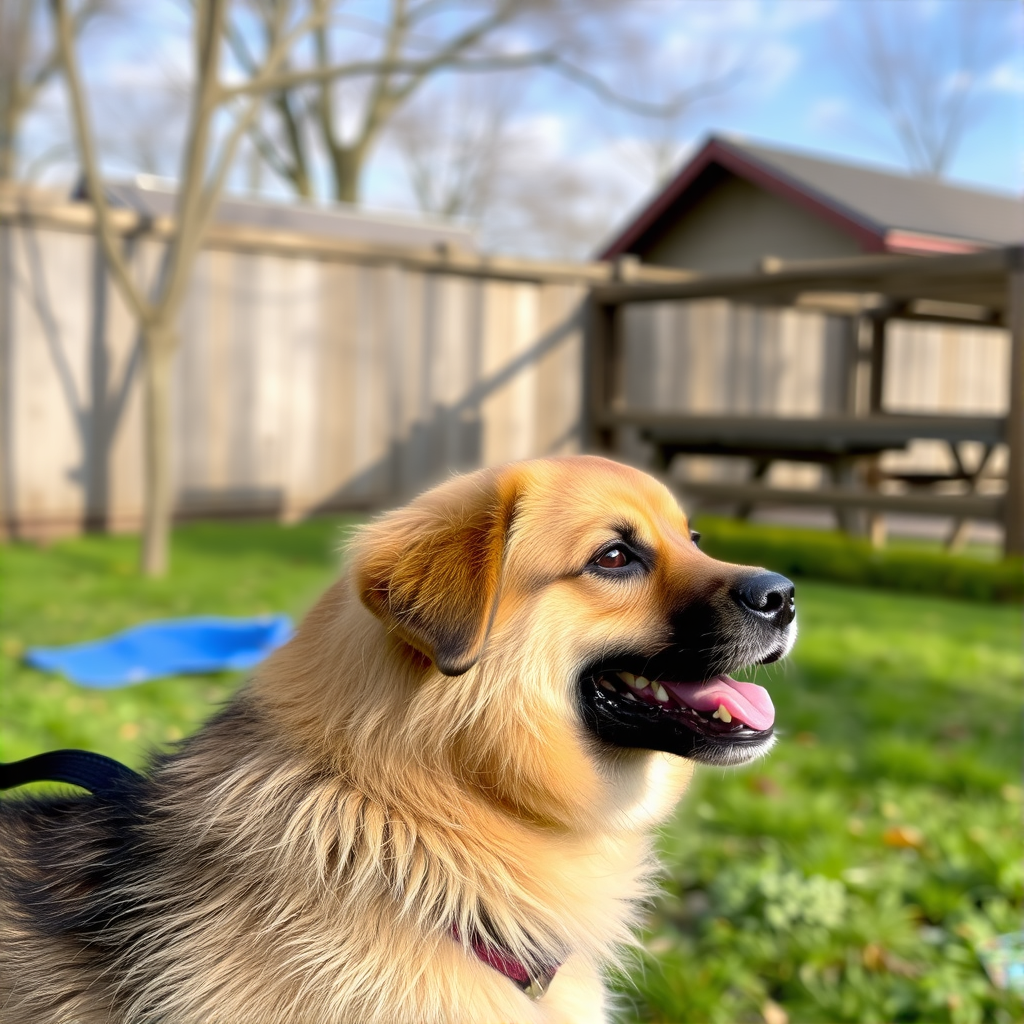

In [106]:
import time
seed = int(time.time())
print(seed)
def _set_nag_attn_processor(
        self,
        nag_scale,
        encoder_hidden_states_length,
        nag_tau=2.5,
        nag_alpha=0.8,
):
    attn_procs = {}
    for name in self.transformer.attn_processors.keys():
        attn_procs[name] = NAGFluxAttnProcessor2_0(
            nag_scale=nag_scale,
            nag_tau=nag_tau,
            nag_alpha=nag_alpha,
            encoder_hidden_states_length=encoder_hidden_states_length,
        )
    self.transformer.set_attn_processor(attn_procs)

NAGFluxPipeline._set_nag_attn_processor = _set_nag_attn_processor
positive_prompt = "a pet in winter outdoor"
negative_prompt = "snow"
image_ours = pipe(
    positive_prompt,
    guidance_scale=0.,
    nag_negative_prompt=negative_prompt,
    nag_scale=4,
    generator=torch.Generator(device="cuda").manual_seed(seed),
    num_inference_steps=5,
    max_sequence_length=256,
).images[0]
image_ours


  0%|          | 0/5 [00:00<?, ?it/s]

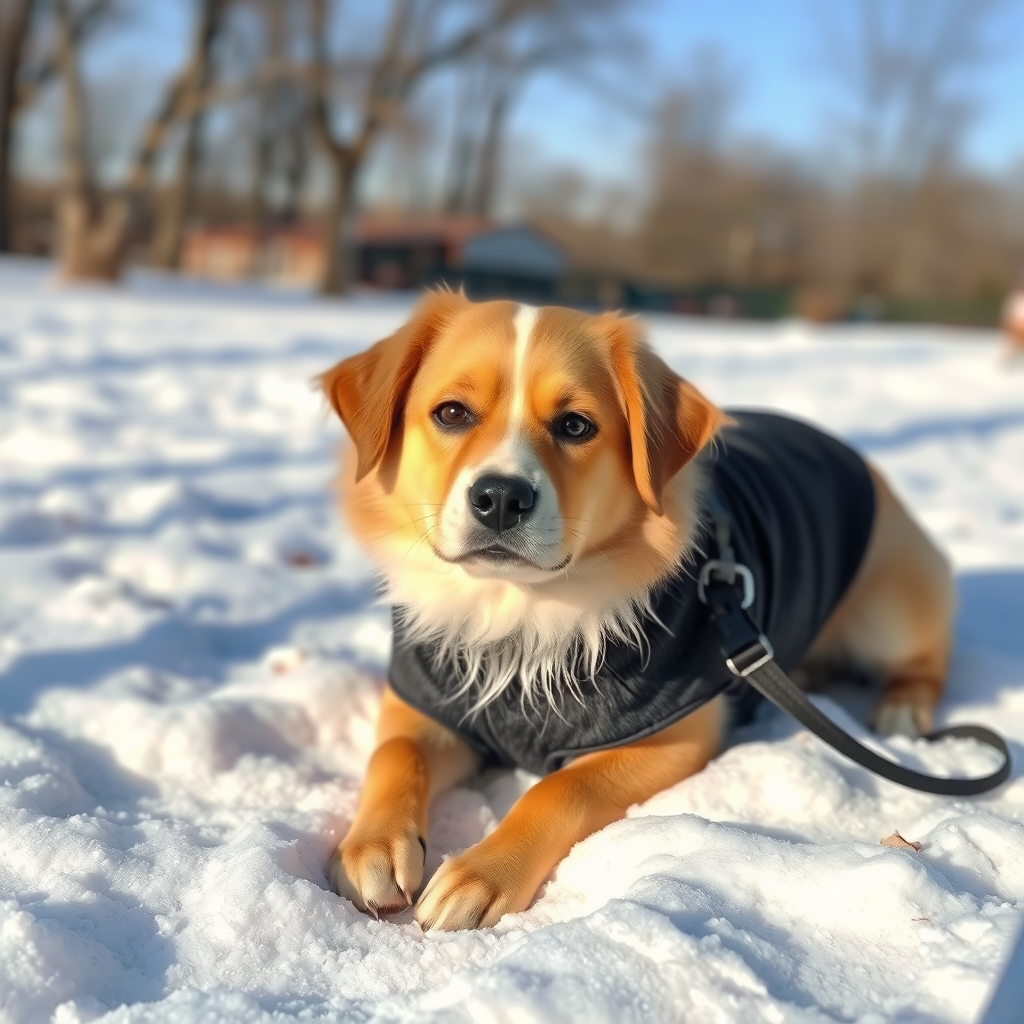

In [108]:
def _set_nag_attn_processor(
        self,
        nag_scale,
        encoder_hidden_states_length,
        nag_tau=5,
        nag_alpha=0.8,
):
    attn_procs = {}
    for name in self.transformer.attn_processors.keys():
        attn_procs[name] = NAGFluxAttnProcessor2_0_vanilla(
            nag_scale=nag_scale,
            nag_tau=nag_tau,
            nag_alpha=nag_alpha,
            encoder_hidden_states_length=encoder_hidden_states_length,
        )
    self.transformer.set_attn_processor(attn_procs)

NAGFluxPipeline._set_nag_attn_processor = _set_nag_attn_processor

image_vanilla = pipe(
    positive_prompt,
    guidance_scale=0.,
    nag_negative_prompt=negative_prompt,
    nag_scale=4,
    generator=torch.Generator(device="cuda").manual_seed(seed),
    num_inference_steps=5,
    max_sequence_length=256,
).images[0]
image_vanilla
